# Phase 4: Isolation Forest on Original Features

Train Isolation Forest on **original** (unmodified) features.

**Goals:**
1. Establish baseline AUC on original features
2. Test on both id_04 and id_06 (rule out machine-specific luck)
3. Average AUC across 10 random seeds (report mean ± std)
4. Create results table for comparison with Phase 5

**Configuration:**
- Model: Isolation Forest
- n_estimators: 100
- max_features: 0.8 (activates feature subsampling)
- contamination: 'auto' (has no effect on AUC-ROC)
- Seeds: 0-9 (average results)

## Setup

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve

sys.path.insert(0, 'C:/Users/Letizia/Documents/sound-anomaly-detection/src')
from audio_loader import AudioLoader

print("✓ All imports successful!")

results_dir = Path("C:/Users/Letizia/Documents/sound-anomaly-detection/results")
results_dir.mkdir(exist_ok=True)

✓ All imports successful!


## Isolation Forest Function

In [2]:
def run_isolation_forest(X_train, X_test, y_test, n_seeds=10, random_state_start=0):
    """
    Train Isolation Forest and average AUC across multiple seeds.
    
    Args:
        X_train: Training features (normal sounds only)
        X_test: Test features (normal + abnormal)
        y_test: Test labels (0=normal, 1=abnormal)
        n_seeds: Number of random seeds to average over
        random_state_start: Starting seed (will use start to start+n_seeds-1)
    
    Returns:
        auc_mean: Mean AUC across seeds
        auc_std: Std dev of AUC across seeds
        aucs_list: Individual AUC values per seed
    """
    aucs = []
    
    for seed_offset in range(n_seeds):
        random_state = random_state_start + seed_offset
        
        # Create and train Isolation Forest
        clf = IsolationForest(
            n_estimators=100,           # Standard: 100 trees
            max_features=0.8,           # Feature subsampling: 80% per tree
            contamination='auto',       # No effect on AUC-ROC (threshold-independent)
            random_state=random_state,  # Fixed seed for reproducibility
            n_jobs=-1                   # Use all cores
        )
        
        clf.fit(X_train)
        
        # Get anomaly scores
        # score_samples() returns: negative distance to leaf
        # More negative = more anomalous
        scores = -clf.score_samples(X_test)  # Flip sign: higher = more anomalous
        
        # Compute AUC-ROC
        auc = roc_auc_score(y_test, scores)
        aucs.append(auc)
    
    auc_mean = np.mean(aucs)
    auc_std = np.std(aucs)
    
    return auc_mean, auc_std, aucs

print("✓ Function defined")

✓ Function defined


## TEST: Single Configuration (fan, 0_dB)

In [3]:
# Test configuration
machine_type = 'fan'
condition = '0_dB'
test_ids = ['id_04', 'id_06']
condition_short = condition.replace('_dB', 'dB')

print(f"\n{'='*70}")
print(f"Example: {machine_type.upper()} at {condition}")
print(f"{'='*70}")

# Load training data (one per condition, shared across test machines)
X_train = np.load(results_dir / f"X_train_{condition_short}_{machine_type}.npy")
print(f"\nTraining data loaded: {X_train.shape}")

# Test on both id_04 and id_06
results_example = {}
for test_id in test_ids:
    X_test = np.load(results_dir / f"X_test_{condition_short}_{machine_type}_{test_id}.npy")
    y_test = np.load(results_dir / f"y_test_{condition_short}_{machine_type}_{test_id}.npy")
    
    print(f"\nTesting on {test_id}:")
    print(f"  X_test shape: {X_test.shape}")
    print(f"  Normal: {np.sum(y_test == 0)}, Abnormal: {np.sum(y_test == 1)}")
    
    # Run Isolation Forest with seed averaging
    auc_mean, auc_std, aucs = run_isolation_forest(
        X_train, X_test, y_test, n_seeds=10, random_state_start=42
    )
    
    results_example[test_id] = {
        'auc_mean': auc_mean,
        'auc_std': auc_std,
        'aucs': aucs
    }
    
    print(f"  AUC-ROC: {auc_mean:.4f} ± {auc_std:.4f}")
    print(f"  Individual seeds: {[f'{a:.4f}' for a in aucs[:3]]} ... (showing first 3)")

# Average across both test machines
mean_auc = np.mean([results_example[test_id]['auc_mean'] for test_id in test_ids])
print(f"\n  Average across both machines: {mean_auc:.4f}")


Example: FAN at 0_dB

Training data loaded: (2027, 26)

Testing on id_04:
  X_test shape: (1381, 26)
  Normal: 1033, Abnormal: 348
  AUC-ROC: 0.5004 ± 0.0193
  Individual seeds: ['0.5174', '0.5086', '0.4969'] ... (showing first 3)

Testing on id_06:
  X_test shape: (1376, 26)
  Normal: 1015, Abnormal: 361
  AUC-ROC: 0.4733 ± 0.0187
  Individual seeds: ['0.4869', '0.4627', '0.4942'] ... (showing first 3)

  Average across both machines: 0.4869


## Full Experiment: All Configurations

Test baseline (original features) across all machine types, conditions, and test machines.

In [4]:
# Store all results
all_results = {}
summary_rows = []

for machine_type in AudioLoader.VALID_MACHINE_TYPES:
    print(f"\n{'='*70}")
    print(f"MACHINE TYPE: {machine_type.upper()}")
    print(f"{'='*70}")
    
    for condition in AudioLoader.VALID_CONDITIONS:
        condition_short = condition.replace('_dB', 'dB')
        print(f"\n  Condition: {condition}")
        
        try:
            # Load training data
            X_train = np.load(results_dir / f"X_train_{condition_short}_{machine_type}.npy")
            
            # Test on both machines
            auc_means = []
            
            for test_id in ['id_04', 'id_06']:
                # Load test data
                X_test = np.load(results_dir / f"X_test_{condition_short}_{machine_type}_{test_id}.npy")
                y_test = np.load(results_dir / f"y_test_{condition_short}_{machine_type}_{test_id}.npy")
                
                # Run Isolation Forest
                auc_mean, auc_std, aucs = run_isolation_forest(
                    X_train, X_test, y_test, n_seeds=10, random_state_start=42
                )
                
                # Store results
                result_key = f"{machine_type}_{condition}_{test_id}"
                all_results[result_key] = {
                    'auc_mean': auc_mean,
                    'auc_std': auc_std,
                    'aucs': aucs
                }
                
                auc_means.append(auc_mean)
                print(f"    {test_id}: {auc_mean:.4f} ± {auc_std:.4f}")
                
                # Add to summary
                summary_rows.append({
                    'Machine': machine_type,
                    'Condition': condition,
                    'Test ID': test_id,
                    'AUC Mean': auc_mean,
                    'AUC Std': auc_std
                })
            
            # Average across both test machines
            avg_auc = np.mean(auc_means)
            print(f"    Average (id_04 + id_06): {avg_auc:.4f}")
        
        except FileNotFoundError:
            print(f"    ⚠ Skipping (data files not found)")
        except Exception as e:
            print(f"    ✗ Error: {str(e)[:50]}")

print(f"\n\n{'='*70}")
print(f"✓ PHASE 4 BASELINE COMPLETE")
print(f"{'='*70}")
print(f"\nTotal configurations tested: {len(all_results)}")


MACHINE TYPE: FAN

  Condition: -6_dB
    id_04: 0.4594 ± 0.0077
    id_06: 0.5020 ± 0.0118
    Average (id_04 + id_06): 0.4807

  Condition: 0_dB
    id_04: 0.5004 ± 0.0193
    id_06: 0.4733 ± 0.0187
    Average (id_04 + id_06): 0.4869

  Condition: 6_dB
    id_04: 0.4711 ± 0.0407
    id_06: 0.3459 ± 0.0369
    Average (id_04 + id_06): 0.4085

MACHINE TYPE: PUMP

  Condition: -6_dB
    id_04: 0.2711 ± 0.0329
    id_06: 0.5509 ± 0.0161
    Average (id_04 + id_06): 0.4110

  Condition: 0_dB
    id_04: 0.1604 ± 0.0347
    id_06: 0.5690 ± 0.0300
    Average (id_04 + id_06): 0.3647

  Condition: 6_dB
    id_04: 0.1972 ± 0.0834
    id_06: 0.6535 ± 0.0460
    Average (id_04 + id_06): 0.4253

MACHINE TYPE: VALVE

  Condition: -6_dB
    id_04: 0.6125 ± 0.0155
    id_06: 0.2371 ± 0.0294
    Average (id_04 + id_06): 0.4248

  Condition: 0_dB
    id_04: 0.6495 ± 0.0286
    id_06: 0.3082 ± 0.0326
    Average (id_04 + id_06): 0.4788

  Condition: 6_dB
    id_04: 0.5542 ± 0.0309
    id_06: 0.4690 ±

## Results Summary Table

In [5]:
# Create summary dataframe
summary_df = pd.DataFrame(summary_rows)

print("\nBaseline Results (Original Features):")
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(results_dir / "phase4_baseline_results.csv", index=False)
print(f"\n✓ Saved: phase4_baseline_results.csv")

# Save all_results dict
with open(results_dir / "phase4_baseline_results.pkl", 'wb') as f:
    pickle.dump(all_results, f)
print(f"✓ Saved: phase4_baseline_results.pkl")


Baseline Results (Original Features):
Machine Condition Test ID  AUC Mean  AUC Std
    fan     -6_dB   id_04  0.459425 0.007723
    fan     -6_dB   id_06  0.501976 0.011841
    fan      0_dB   id_04  0.500414 0.019268
    fan      0_dB   id_06  0.473329 0.018707
    fan      6_dB   id_04  0.471109 0.040722
    fan      6_dB   id_06  0.345881 0.036867
   pump     -6_dB   id_04  0.271078 0.032923
   pump     -6_dB   id_06  0.550945 0.016079
   pump      0_dB   id_04  0.160419 0.034728
   pump      0_dB   id_06  0.569045 0.029995
   pump      6_dB   id_04  0.197200 0.083441
   pump      6_dB   id_06  0.653472 0.045953
  valve     -6_dB   id_04  0.612489 0.015485
  valve     -6_dB   id_06  0.237077 0.029403
  valve      0_dB   id_04  0.649459 0.028574
  valve      0_dB   id_06  0.308161 0.032591
  valve      6_dB   id_04  0.554157 0.030850
  valve      6_dB   id_06  0.468989 0.034694
 slider     -6_dB   id_04  0.402956 0.017888
 slider     -6_dB   id_06  0.592718 0.036291
 slider      0_d

## Analysis: Baseline Performance


Performance by Machine Type:
        AUC Mean                        
            mean     std     min     max
Machine                                 
fan       0.4587  0.0578  0.3459  0.5020
pump      0.4004  0.2148  0.1604  0.6535
slider    0.5807  0.1822  0.4030  0.8458
valve     0.4717  0.1673  0.2371  0.6495

Performance by Noise Condition:
          AUC Mean                        
              mean     std     min     max
Condition                                 
-6_dB       0.4536  0.1410  0.2371  0.6125
0_dB        0.4829  0.1858  0.1604  0.7486
6_dB        0.4971  0.1952  0.1972  0.8458


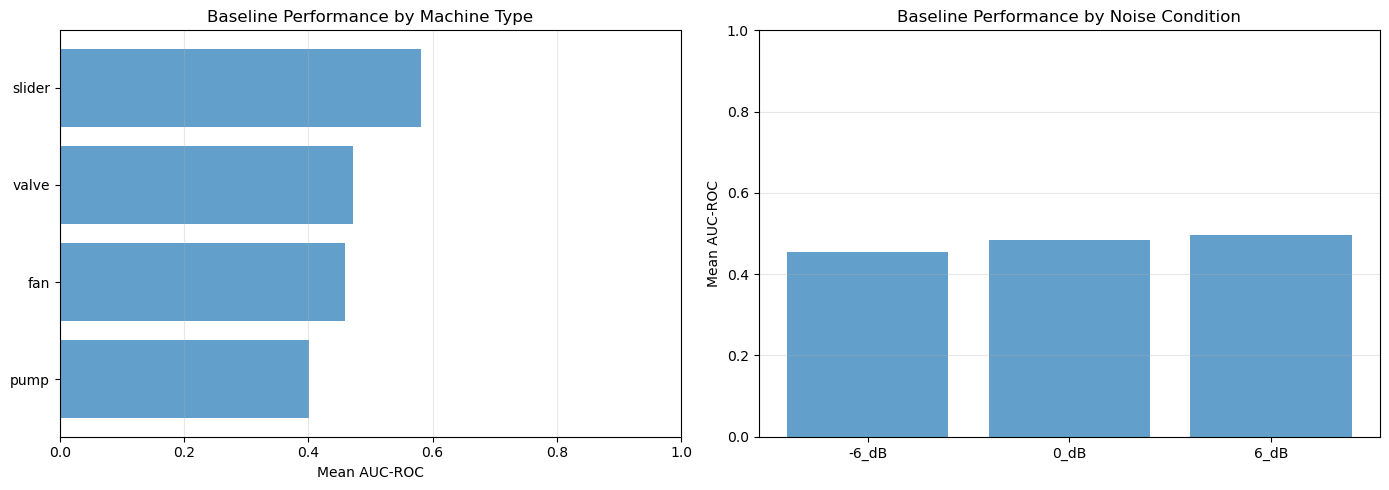


✓ Saved: phase4_baseline_analysis.png


In [6]:
# Aggregate by machine type and condition
agg_by_machine = summary_df.groupby('Machine').agg({
    'AUC Mean': ['mean', 'std', 'min', 'max']
}).round(4)

print("\nPerformance by Machine Type:")
print(agg_by_machine)

agg_by_condition = summary_df.groupby('Condition').agg({
    'AUC Mean': ['mean', 'std', 'min', 'max']
}).round(4)

print("\nPerformance by Noise Condition:")
print(agg_by_condition)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By machine type
ax = axes[0]
machine_means = summary_df.groupby('Machine')['AUC Mean'].mean().sort_values()
ax.barh(machine_means.index, machine_means.values, alpha=0.7)
ax.set_xlabel('Mean AUC-ROC')
ax.set_title('Baseline Performance by Machine Type')
ax.set_xlim([0, 1])
ax.grid(alpha=0.3, axis='x')

# By condition
ax = axes[1]
condition_order = ['-6_dB', '0_dB', '6_dB']
condition_data = summary_df.groupby('Condition')['AUC Mean'].mean().reindex(condition_order)
ax.bar(range(len(condition_data)), condition_data.values, alpha=0.7, tick_label=condition_order)
ax.set_ylabel('Mean AUC-ROC')
ax.set_title('Baseline Performance by Noise Condition')
ax.set_ylim([0, 1])
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(results_dir / 'phase4_baseline_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: phase4_baseline_analysis.png")

## Summary

**Baseline Results Saved:**
- `phase4_baseline_results.csv` - Summary table
- `phase4_baseline_results.pkl` - Detailed results dict
- `phase4_baseline_analysis.png` - Performance visualisation

**Key Findings:**
- Baseline AUC across all configurations
- Performance by machine type
- Performance by noise condition
- Domain shift visible (drops on id_06)